# Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Upload Data and split X and Y

In [3]:
PATH = '../dataset/CaracteristicasExtraidasdeMascaras.xlsx'
df = pd.read_excel(PATH)

# Select only characteristics and labels
X = df[['Texture', 'Perimeter', 'Cx', 'Cy', 'Concave', 'Concave_Points', 'Smoothness']].values
y = df['Label'].values

In [4]:
X.shape, y.shape

((665, 7), (665,))

In [5]:
df.head()

,Mascara de donde se extraen características,Texture,Perimeter,Cx,Cy,Concave,Concave_Points,Smoothness,Label
0,1,120.465873,717.002087,127,117,1.090374,220,9,1
1,2,43.380253,193.539104,143,47,1.143877,64,8,1
2,3,60.315121,317.178713,127,69,1.216962,117,10,1
3,4,87.914507,560.173660,125,110,1.312826,191,8,1
4,5,84.541220,490.475175,106,136,1.210341,175,10,1


# Little Preproc

In [6]:
X_min = X.min(axis=0) # Normalziation Min-Max
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

# Add Bias
X_norm = np.hstack([np.ones((X_norm.shape[0], 1)), X_norm])

X_norm.shape

(665, 8)

In [7]:
# Valid normalization
print("Min values after normalization:", X_norm.min(axis=0))
print("Max values after normalization:", X_norm.max(axis=0))
print("Min values before normalization:", X.min(axis=0))
print("Max values before normalization:", X.max(axis=0))

Min values after normalization: [1. 0. 0. 0. 0. 0. 0. 0.]
Max values after normalization: [1. 1. 1. 1. 1. 1. 1. 1.]
Min values before normalization: [11.54408454 43.5563488  24.         21.          1.00948973  5.
  4.        ]
Max values before normalization: [127.22755927 851.61225891 233.         170.           1.48216421
 307.          13.        ]


# Split data (Train, valid and test)

In [8]:
def split_stratified(X, y, train_p=0.7, valid_p=0.15, test_p=0.15):
    idx_0 = np.where(y == 0)[0] # search for benign samples
    idx_1 = np.where(y == 1)[0]# search for malignant samples
    
    # Shuffle indices to ensure randomness
    np.random.seed(42)
    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)
    
    # Calculate cut points for each class
    cut_train_0 = int(len(idx_0) * train_p)
    cut_valid_0 = int(len(idx_0) * (train_p + valid_p))
    
    # Calculate cut points for class 1
    cut_train_1 = int(len(idx_1) * train_p)
    cut_valid_1 = int(len(idx_1) * (train_p + valid_p))
    
    # Combine indices for train, valid, and test sets
    train_idx = np.concatenate([idx_0[:cut_train_0], idx_1[:cut_train_1]])
    valid_idx = np.concatenate([idx_0[cut_train_0:cut_valid_0], idx_1[cut_train_1:cut_valid_1]])
    test_idx = np.concatenate([idx_0[cut_valid_0:], idx_1[cut_valid_1:]])
    
    # Shuffle the combined indices to ensure randomness in the final splits
    np.random.shuffle(train_idx)
    np.random.shuffle(valid_idx)
    np.random.shuffle(test_idx)
    
    return train_idx, valid_idx, test_idx

train_idx, valid_idx, test_idx = split_stratified(X_norm, y)

X_train, y_train = X_norm[train_idx], y[train_idx]
X_val,   y_val   = X_norm[valid_idx], y[valid_idx]
X_test,  y_test  = X_norm[test_idx],  y[test_idx]

# Valid balanced splits
print("Train set - Benign samples:", np.sum(y_train == 0), "Malignant samples:", np.sum(y_train == 1))
print("Validation set - Benign samples:", np.sum(y_val == 0), "Malignant samples:", np.sum(y_val == 1))
print("Test set - Benign samples:", np.sum(y_test == 0), "Malignant samples:", np.sum(y_test == 1))

Train set - Benign samples: 317 Malignant samples: 147
Validation set - Benign samples: 68 Malignant samples: 32
Test set - Benign samples: 69 Malignant samples: 32


# Train Loop and Auxiliar function

In [9]:
def train_lms(X_t, y_t, X_v, y_v, lr=0.01, epochs=100):
    print("Starting training... with learning rate:", lr, "and epochs:", epochs)
    n_samples, n_features = X_t.shape # Number of samples and features
    weights = np.random.randn(n_features) * 0.01 # Init weights small random values
    
    train_history = [] # To store training error history
    val_history = [] # To store validation error history
    
    for epoch in range(epochs):
        # train and update weights
        epoch_error_t = 0 # Accumulate training error for this epoch
        for i in range(n_samples):
            prediction = np.dot(X_t[i], weights) # Linear output
            error = y_t[i] - prediction # Calculate error
            # Update weights using LMS rule
            weights += lr * error * X_t[i]
            epoch_error_t += error**2 # Accumulate squared error for MSE
            
        # Validation
        val_predictions = np.dot(X_v, weights)
        val_error = np.mean((y_v - val_predictions)**2)
        
        train_history.append(epoch_error_t / n_samples)
        val_history.append(val_error)

        print(f"Epoch {epoch+1}/{epochs} - Train MSE: {train_history[-1]:.4f} - Val MSE: {val_history[-1]:.4f}")
        
    return weights, train_history, val_history

def get_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

def get_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return f1, recall, precision

# Loop to hyperparameters Analysis

Starting training... with learning rate: 0.01 and epochs: 50
Epoch 1/50 - Train MSE: 0.1668 - Val MSE: 0.1426
Epoch 2/50 - Train MSE: 0.1330 - Val MSE: 0.1186
Epoch 3/50 - Train MSE: 0.1174 - Val MSE: 0.1041
Epoch 4/50 - Train MSE: 0.1080 - Val MSE: 0.0941
Epoch 5/50 - Train MSE: 0.1015 - Val MSE: 0.0864
Epoch 6/50 - Train MSE: 0.0967 - Val MSE: 0.0804
Epoch 7/50 - Train MSE: 0.0931 - Val MSE: 0.0755
Epoch 8/50 - Train MSE: 0.0903 - Val MSE: 0.0714
Epoch 9/50 - Train MSE: 0.0882 - Val MSE: 0.0681
Epoch 10/50 - Train MSE: 0.0865 - Val MSE: 0.0653
Epoch 11/50 - Train MSE: 0.0852 - Val MSE: 0.0630
Epoch 12/50 - Train MSE: 0.0842 - Val MSE: 0.0611
Epoch 13/50 - Train MSE: 0.0834 - Val MSE: 0.0594
Epoch 14/50 - Train MSE: 0.0828 - Val MSE: 0.0580
Epoch 15/50 - Train MSE: 0.0822 - Val MSE: 0.0568
Epoch 16/50 - Train MSE: 0.0818 - Val MSE: 0.0558
Epoch 17/50 - Train MSE: 0.0815 - Val MSE: 0.0549
Epoch 18/50 - Train MSE: 0.0812 - Val MSE: 0.0541
Epoch 19/50 - Train MSE: 0.0810 - Val MSE: 0.053

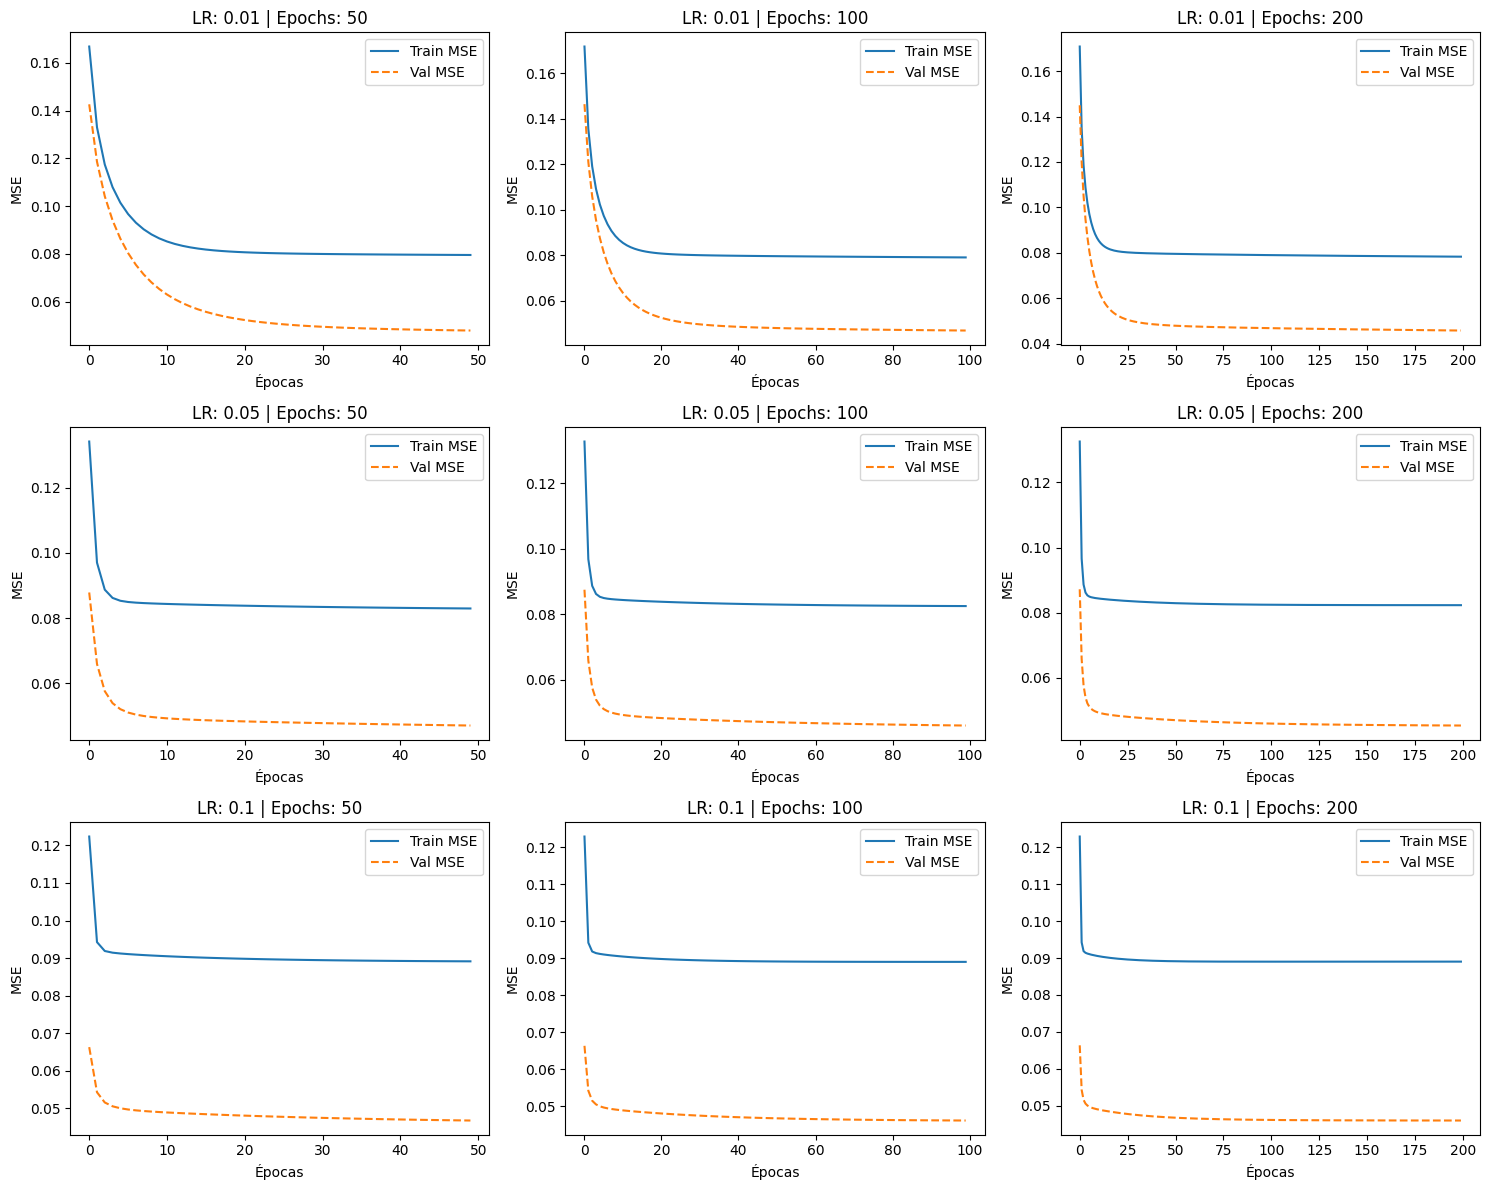

In [10]:
learning_rates = [0.01, 0.05, 0.1]
epochs_list = [50, 100, 200]

plt.figure(figsize=(15, 12))
plot_idx = 1


for lr in learning_rates:
    for epochs in epochs_list:
        # Train model and measure time
        start_time = time.time()
        w, h_train, h_val = train_lms(X_train, y_train, X_val, y_val, lr=lr, epochs=epochs)
        duration = time.time() - start_time
        
        # predictions and accuracy
        y_train_pred = (np.dot(X_train, w) >= 0.5).astype(int) # Threshold at 0.5 for binary classification
        y_val_pred = (np.dot(X_val, w) >= 0.5).astype(int) # Threshold at 0.5 for binary classification
        
        # metrics
        acc_val = np.mean(y_val_pred == y_val)
        f1_val, recall_val, prec_val = get_metrics(y_val, y_val_pred)
        acc_train = np.mean(y_train_pred == y_train)
        f1_train, recall_train, prec_train = get_metrics(y_train, y_train_pred)
        
        # confusion matrix for validation set
        cm_val = get_confusion_matrix(y_val, y_val_pred)
        
        # print results
        # table header
        print(f"{'LR':<6} | {'Epochs':<8} | {'Time(s)':<8} | {'F1 Train':<10} | {'F1 Val':<10}")
        print("-" * 90)
        print(f"{lr:<6} | {epochs:<8} | {duration:<8.4f} | {f1_train:<10.2%} | {f1_val:<10.2%}")
        print(f"Confusion Matrix (Val) to LR={lr}, Ep={epochs}:\n{cm_val}\n")
        
        # plot training and validation error
        plt.subplot(3, 3, plot_idx)
        plt.plot(h_train, label='Train MSE')
        plt.plot(h_val, label='Val MSE', linestyle='--')
        plt.title(f'LR: {lr} | Epochs: {epochs}')
        plt.xlabel('Épocas')
        plt.ylabel('MSE')
        plt.legend()
        plot_idx += 1

plt.tight_layout()
plt.show()

# Confusion matrix and results with test

In [14]:
y_test_pred = (np.dot(X_test, w) >= 0.5).astype(int)

f1_test, recall_test, precision_test = get_metrics(y_test, y_test_pred)
acc_test = np.mean(y_test_pred == y_test)

cm_test = get_confusion_matrix(y_test, y_test_pred)

print("="*30)
print(" FINAL TEST EVALUATION ")
print("="*30)
print(f"F1-Score:  {f1_test:.4f}")
print(f"Recall:    {recall_test:.2%}")
print(f"Precision: {precision_test:.2%}")
print(f"Accuracy:  {acc_test:.2%}")
print("-" * 30)
print("Confusion Matrix (Test):")
print(cm_test)
print("="*30)

 FINAL TEST EVALUATION 
F1-Score:  0.8772
Recall:    78.12%
Precision: 100.00%
Accuracy:  93.07%
------------------------------
Confusion Matrix (Test):
[[69  0]
 [ 7 25]]


# Surface error

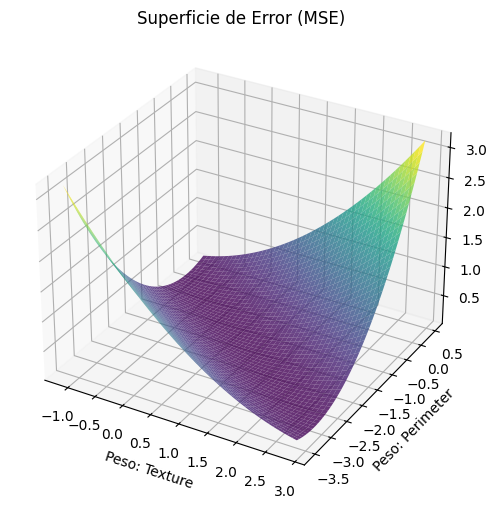

In [12]:
def plot_error_surface(X, y, w_final):
    w1_range = np.linspace(w_final[1] - 2, w_final[1] + 2, 50) # Weights range around the final weight for Texture
    w2_range = np.linspace(w_final[2] - 2, w_final[2] + 2, 50) # Weights range around the final weight for Perimeter
    W1, W2 = np.meshgrid(w1_range, w2_range)
    
    mse_surface = np.zeros(W1.shape)
    
    # Calculate MSE for each combination of the two weights
    for i in range(len(w1_range)):
        for j in range(len(w2_range)):
            w_temp = w_final.copy()
            w_temp[1] = w1_range[i]
            w_temp[2] = w2_range[j]
            preds = np.dot(X, w_temp)
            mse_surface[i, j] = np.mean((y - preds)**2)
            
    # Plot
    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(W1, W2, mse_surface, cmap='viridis', alpha=0.8)
    ax1.set_title('Superficie de Error (MSE)')
    ax1.set_xlabel('Peso: Texture')
    ax1.set_ylabel('Peso: Perimeter')
    plt.show()

plot_error_surface(X_train, y_train, w)

# Matrix Dispersion

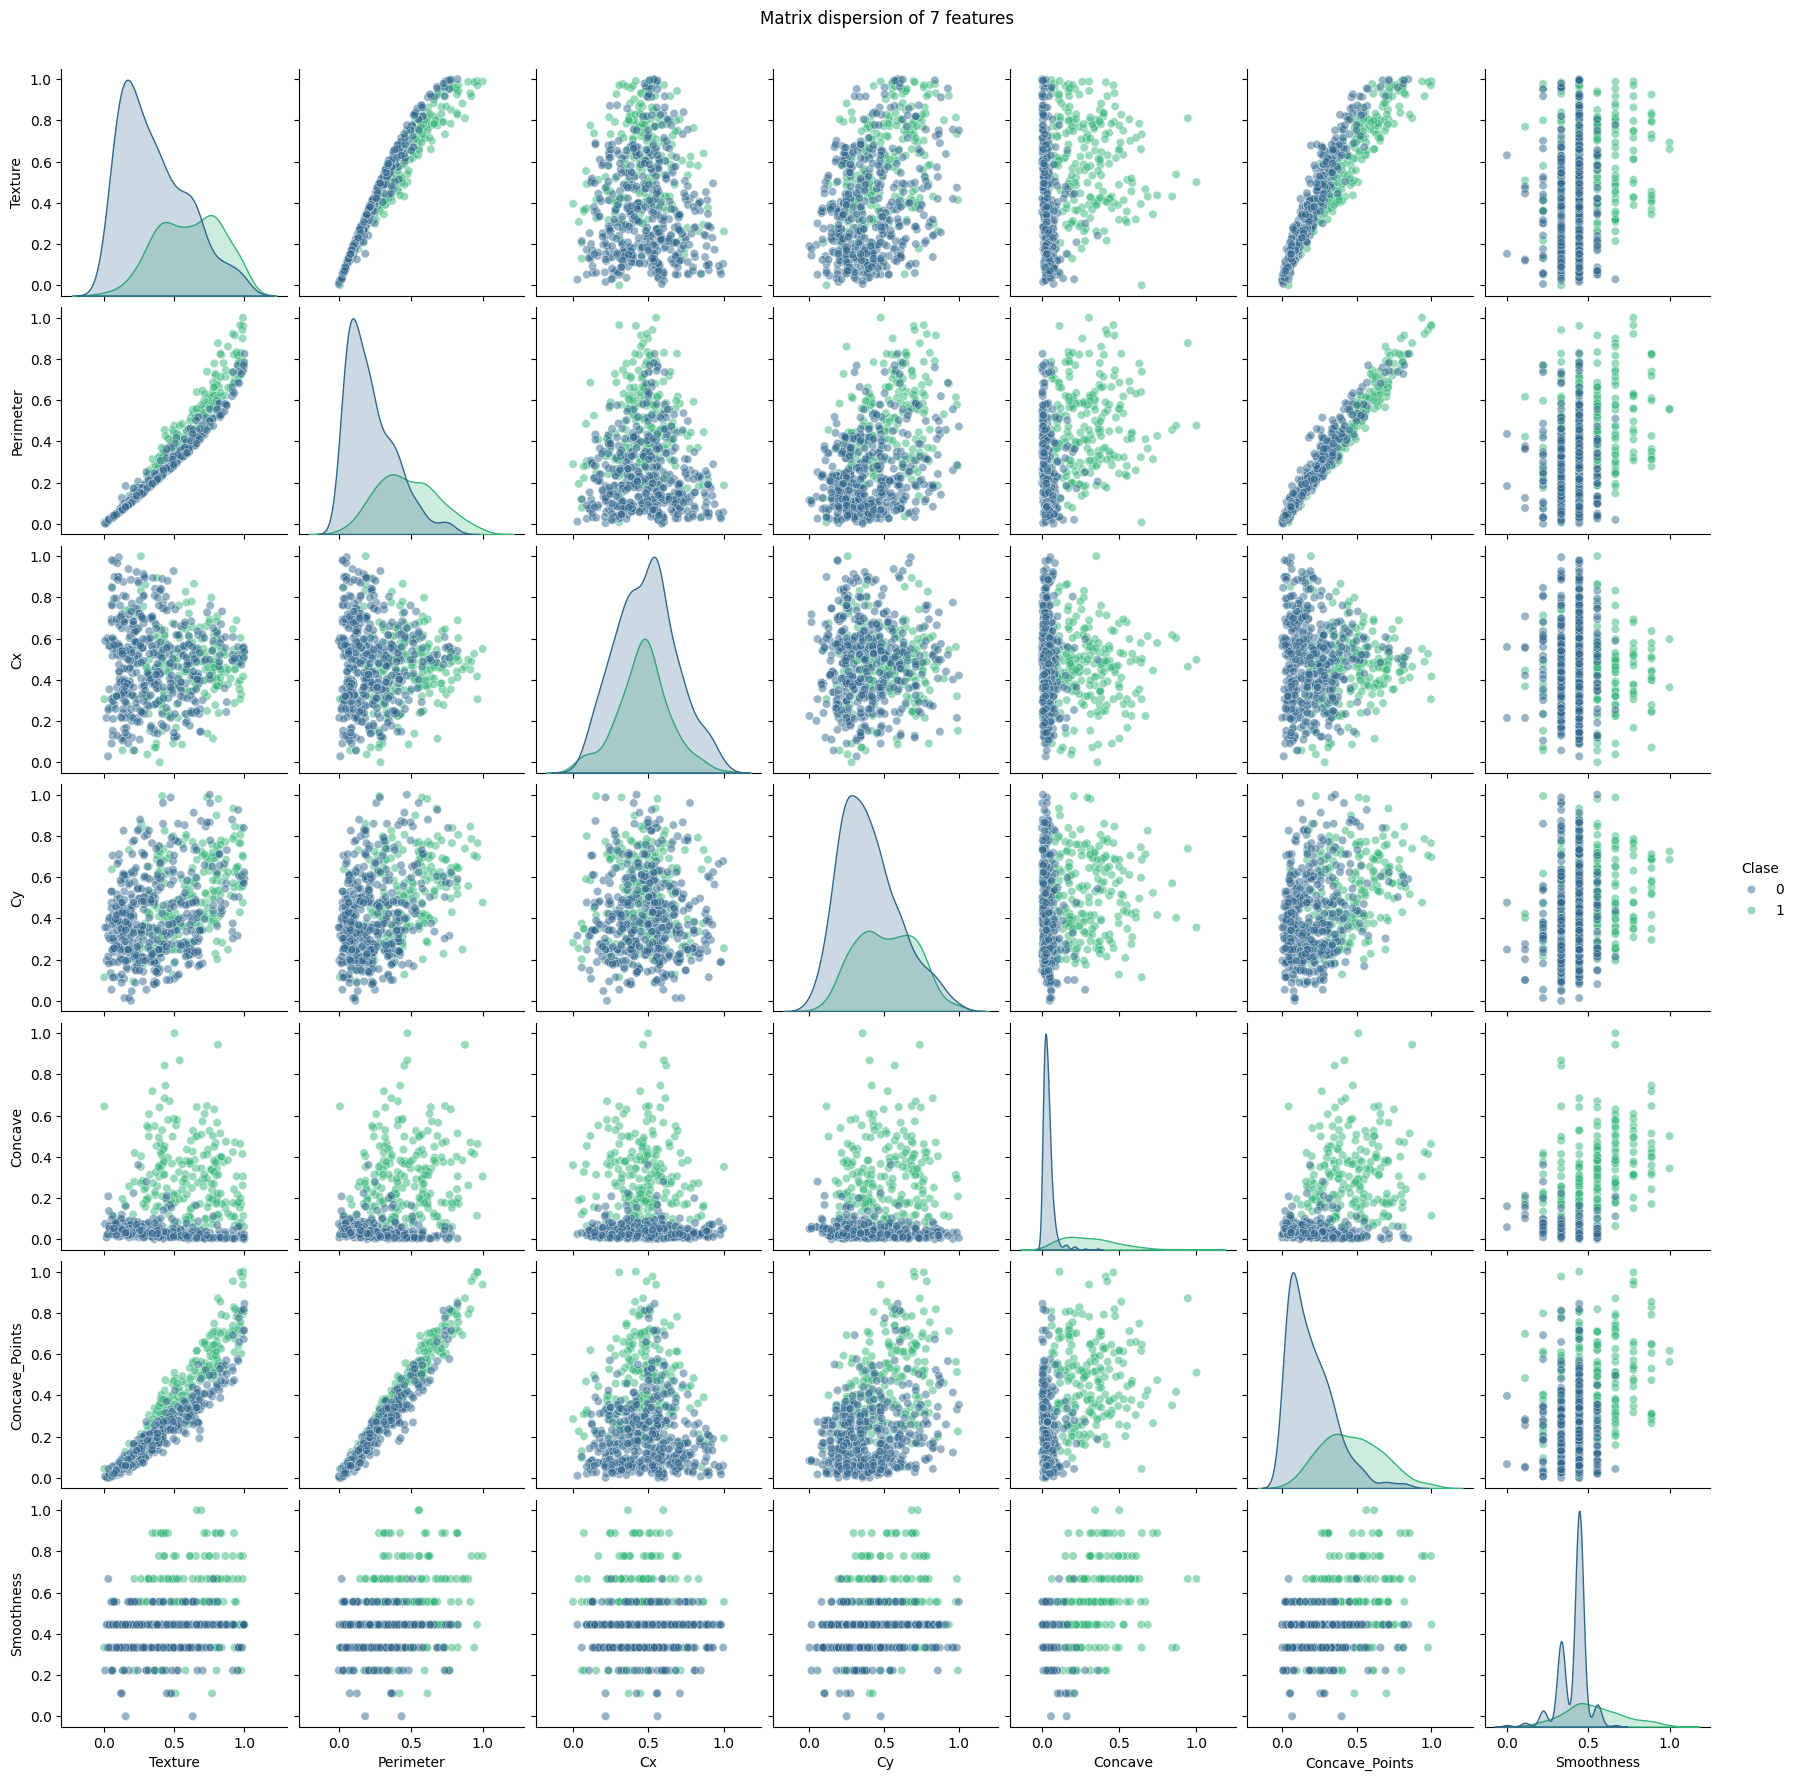

In [13]:
columnas = ['Texture', 'Perimeter', 'Cx', 'Cy', 'Concave', 'Concave_Points', 'Smoothness']
df_plot = pd.DataFrame(X_norm[:, 1:], columns=columnas)
df_plot['Clase'] = y  

grid = sns.pairplot(df_plot, hue='Clase', palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.5})

grid.fig.suptitle('Matrix dispersion of 7 features ', y=1.02)
plt.show()

# Conclusions

- Convergence and Hyperparameters
The study showed that variations in η and epochs did not significantly 
alter MSE, confirming a convex error surface where the global minimum 
is reliably reached regardless of the chosen hyperparameter combination.

- Linear Boundary Performance
Despite its simplicity, the LMS model achieved Precision=100% and 
Accuracy=93.07% on the test set, demonstrating that the extracted 
morphological features (Texture, Perimeter, Concavity) are largely 
linearly separable. However, a Recall of 78.12% (7 missed malignant 
cases) reveals the fundamental limitation of a linear decision boundary 
when handling the overlap between classes in the feature space.

- Generalization vs. Capacity
The minimal gap between training and validation MSE confirms the absence 
of overfitting. However, the 7 false negatives in test indicate that 
the model's limited capacity prevents it from capturing the full 
complexity of malignant patterns, a critical limitation in clinical 
screening where missing a cancer case carries high risk.